文件检查通过
eeg15 标注长度：15416 秒
癫痫发作总秒数：1471 秒

检测到的癫痫发作区间：
第 1 段：0 s 到 23 s，持续 23 s
第 2 段：260 s 到 313 s，持续 53 s
第 3 段：494 s 到 627 s，持续 133 s
第 4 段：750 s 到 883 s，持续 133 s
第 5 段：1510 s 到 1530 s，持续 20 s
第 6 段：1536 s 到 1565 s，持续 29 s
第 7 段：1908 s 到 2075 s，持续 167 s
第 8 段：2452 s 到 2491 s，持续 39 s
第 9 段：2746 s 到 2787 s，持续 41 s
第 10 段：3230 s 到 3281 s，持续 51 s
第 11 段：3481 s 到 3519 s，持续 38 s
第 12 段：3926 s 到 4080 s，持续 154 s
第 13 段：4227 s 到 4288 s，持续 61 s
第 14 段：4362 s 到 4517 s，持续 155 s
第 15 段：5397 s 到 5451 s，持续 54 s
第 16 段：5624 s 到 5665 s，持续 41 s
第 17 段：6090 s 到 6254 s，持续 164 s
第 18 段：6375 s 到 6427 s，持续 52 s
第 19 段：6578 s 到 6641 s，持续 63 s

本次选择持续时间最长的一段进行分析：
癫痫发作开始：1908 s
癫痫发作结束：2075 s
持续时间：167 s


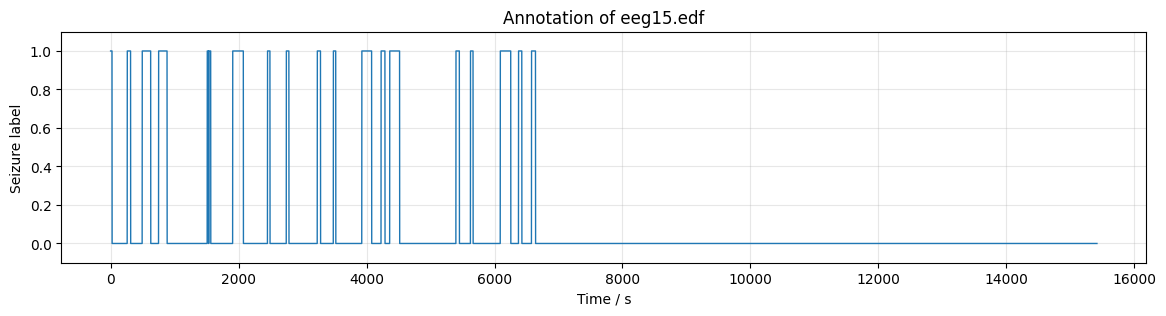


EDF 文件信息：
信号通道数： 21
数据记录数： 6898
每个记录时长： 1.0 s
EDF 总时长： 6898.0 s
通道名：
0 EEG Fp1-REF
1 EEG Fp2-REF
2 EEG F3-REF
3 EEG F4-REF
4 EEG C3-REF
5 EEG C4-REF
6 EEG P3-REF
7 EEG P4-REF
8 EEG O1-REF
9 EEG O2-REF
10 EEG F7-REF
11 EEG F8-REF
12 EEG T3-REF
13 EEG T4-REF
14 EEG T5-REF
15 EEG T6-REF
16 EEG Fz-REF
17 EEG Cz-REF
18 EEG Pz-REF
19 ECG EKG-REF
20 Resp Effort-REF

选择的 EEG 通道数： 19
采样率： 256.0 Hz
选择的 EEG 通道：
0 EEG Fp1-REF
1 EEG Fp2-REF
2 EEG F3-REF
3 EEG F4-REF
4 EEG C3-REF
5 EEG C4-REF
6 EEG P3-REF
7 EEG P4-REF
8 EEG O1-REF
9 EEG O2-REF
10 EEG F7-REF
11 EEG F8-REF
12 EEG T3-REF
13 EEG T4-REF
14 EEG T5-REF
15 EEG T6-REF
16 EEG Fz-REF
17 EEG Cz-REF
18 EEG Pz-REF

分析时间窗：
1898.00 s 到 2085.00 s

读取数据完成
数据形状： (19, 47872)
单位：通常为 EDF 文件中的物理单位，这里一般是 μV


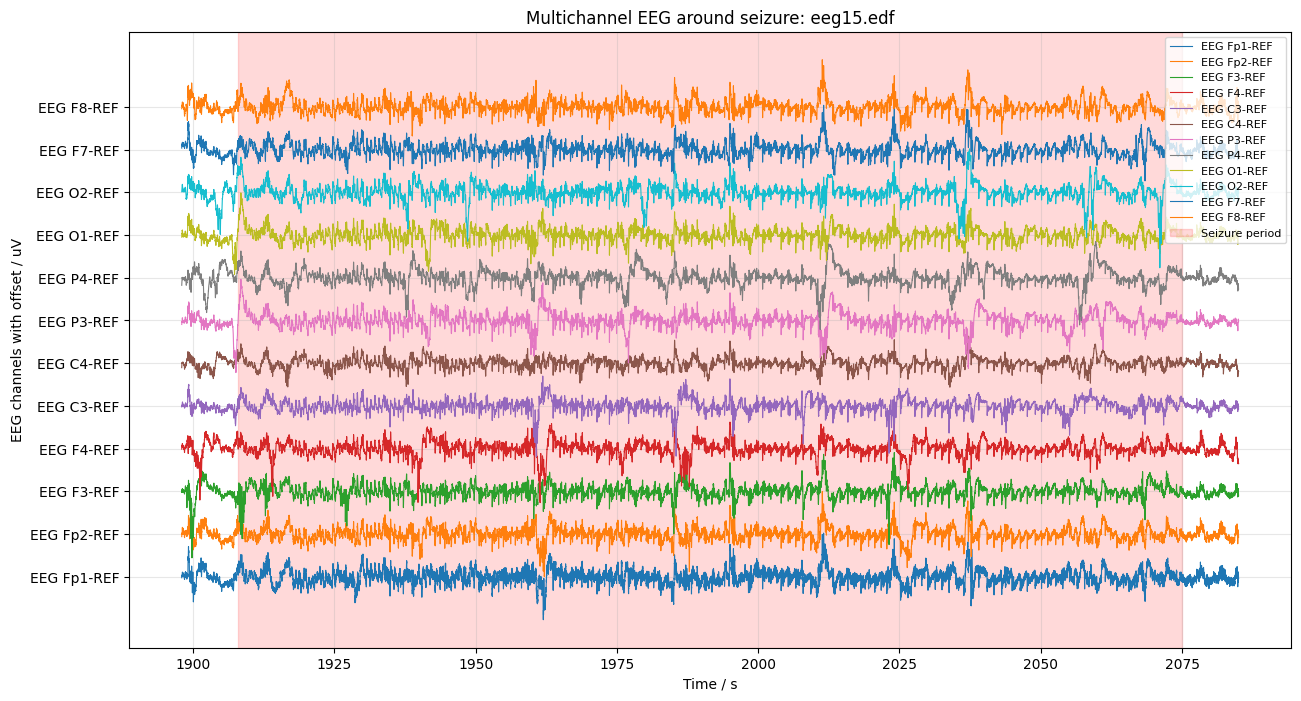

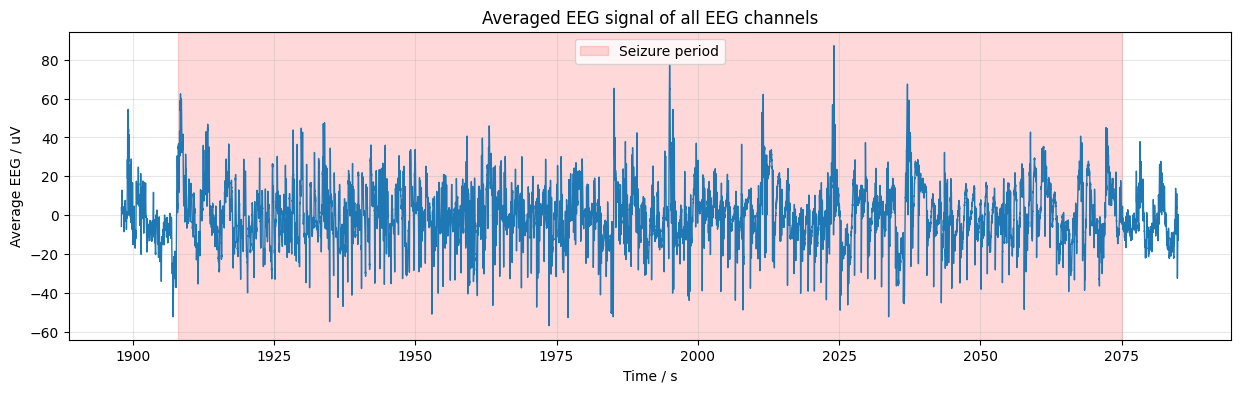

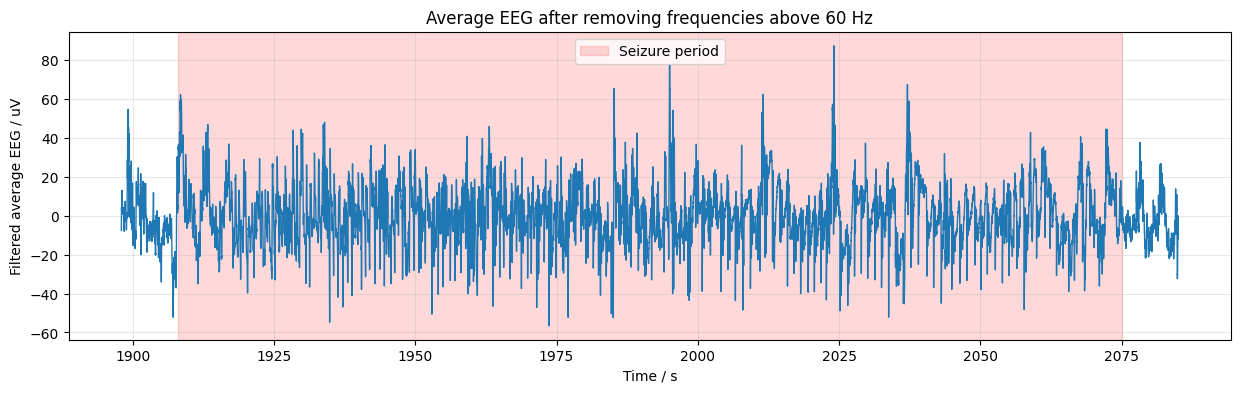

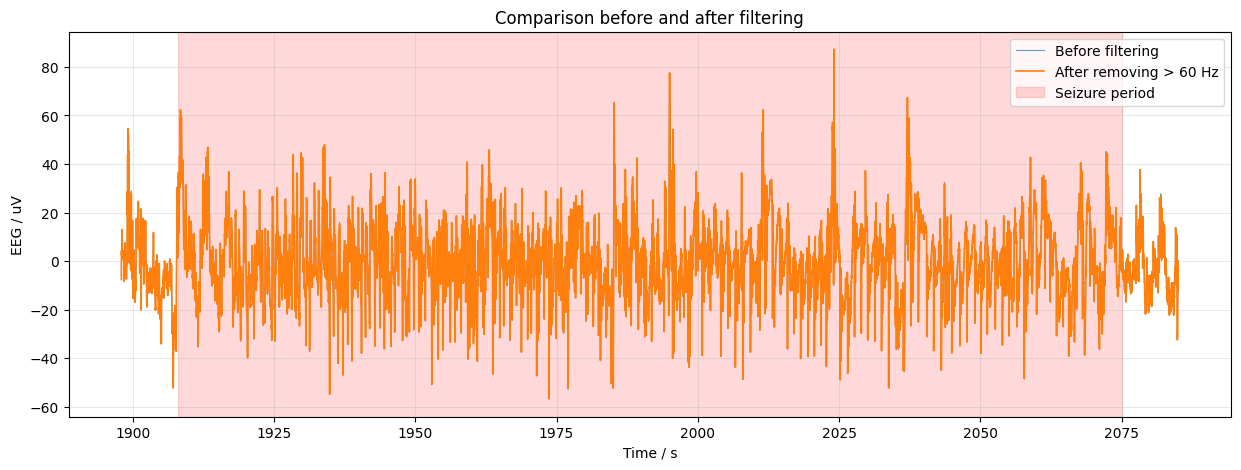

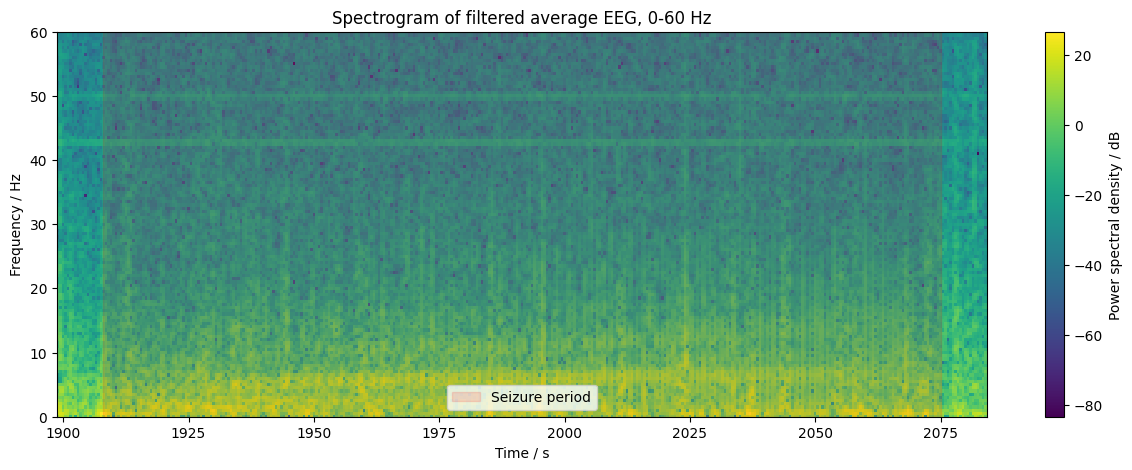


开始计算小波变换，可能需要几十秒，请等待...


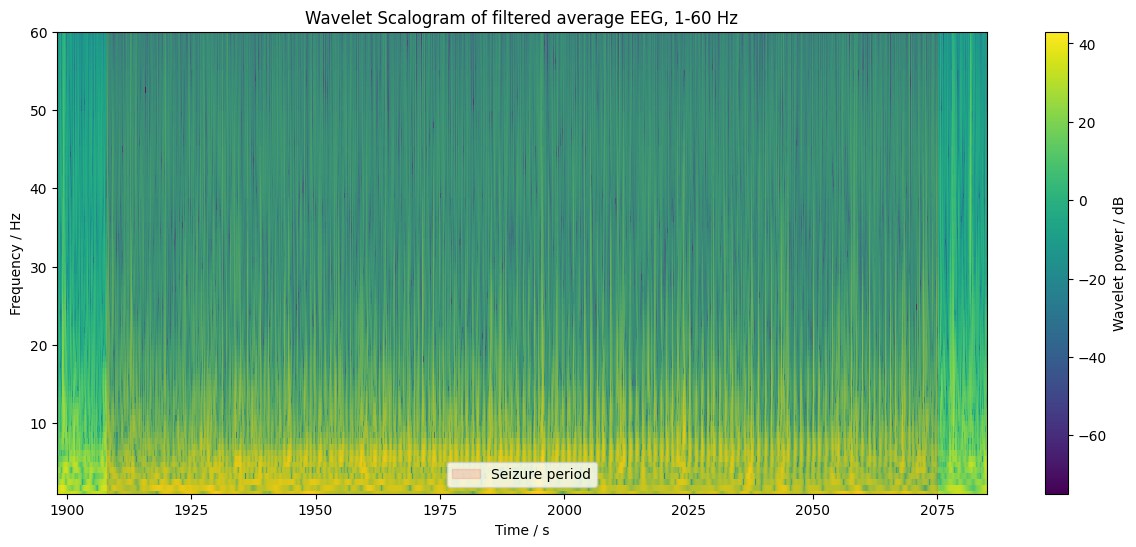


================ 结果总结 ================
使用 EDF 文件：eeg15.edf
使用标注文件：annotations_2017_A.csv
使用第 15 列作为 eeg15.edf 的癫痫发作标注
标注中 1 表示癫痫发作，0 表示非癫痫发作
检测到 19 段癫痫发作
本次分析选取最长发作段：1908 s 到 2075 s
EDF 采样率：256.0 Hz
分析时间窗：1898.00 s 到 2085.00 s
处理流程：读取 EDF → 多通道时域图 → 所有 EEG 通道平均 → 去除 60 Hz 以上频率 → spectrogram → wavelet scalogram


In [2]:
# ============================================================
# EEG15 Seizure Analysis without mne and pywt
#
# 需要的文件：
#   1. eeg15.edf
#   2. annotations_2017_A.csv
#
# 不使用：
#   mne
#   pywt
#   scipy
#   pandas
#
# 只使用：
#   numpy
#   matplotlib
#   os
#   csv
#
# 主要任务：
#   1. 读取 annotation，找到 eeg15 的癫痫发作区间
#   2. 纯 Python 读取 EDF 文件
#   3. 绘制发作附近 EEG 时域图
#   4. 所有 EEG 通道平均
#   5. 去除 60 Hz 以上频率
#   6. 绘制 spectrogram
#   7. 绘制 wavelet scalogram
# ============================================================

import os
import csv
import numpy as np
import matplotlib.pyplot as plt


# =========================
# 1. 参数设置
# =========================

EDF_PATH = "eeg15.edf"
ANN_PATH = "annotations_2017_A.csv"

EEG_ID = 15
LOWPASS_HZ = 60

PRE_TIME = 10
POST_TIME = 10

MAX_CHANNELS_TO_PLOT = 12


# =========================
# 2. 基础检查
# =========================

if not os.path.exists(EDF_PATH):
    raise FileNotFoundError(f"找不到 EDF 文件：{EDF_PATH}")

if not os.path.exists(ANN_PATH):
    raise FileNotFoundError(f"找不到标注文件：{ANN_PATH}")

print("文件检查通过")


# =========================
# 3. 读取 annotation 文件
# =========================

def read_annotation_csv(csv_path, eeg_id):
    """
    读取 annotations_2017_A.csv。
    csv 第一行是列名 1,2,3,...,79。
    eeg15.edf 对应第 15 列。
    """
    with open(csv_path, "r", encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        header = next(reader)
        header = [h.strip() for h in header]

    if str(eeg_id) in header:
        col_idx = header.index(str(eeg_id))
    else:
        col_idx = eeg_id - 1

    data = np.genfromtxt(
        csv_path,
        delimiter=",",
        skip_header=1,
        dtype=float
    )

    label = data[:, col_idx]
    label = np.nan_to_num(label, nan=0)
    label = label.astype(int)

    return label


def find_segments(binary_label):
    """
    找到连续为 1 的区间。
    返回：
        [(start_second, end_second), ...]
    其中 end_second 是结束位置的下一秒。
    """
    binary_label = np.asarray(binary_label).astype(int)
    diff = np.diff(np.r_[0, binary_label, 0])

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    return list(zip(starts, ends))


label = read_annotation_csv(ANN_PATH, EEG_ID)

print(f"eeg{EEG_ID} 标注长度：{len(label)} 秒")
print(f"癫痫发作总秒数：{int(label.sum())} 秒")

seizure_segments = find_segments(label)

if len(seizure_segments) == 0:
    raise ValueError(f"eeg{EEG_ID} 没有找到癫痫发作标注")

print("\n检测到的癫痫发作区间：")
for i, (s, e) in enumerate(seizure_segments, start=1):
    print(f"第 {i} 段：{s} s 到 {e} s，持续 {e - s} s")

durations = np.array([e - s for s, e in seizure_segments])
main_idx = np.argmax(durations)

seizure_start, seizure_end = seizure_segments[main_idx]

print("\n本次选择持续时间最长的一段进行分析：")
print(f"癫痫发作开始：{seizure_start} s")
print(f"癫痫发作结束：{seizure_end} s")
print(f"持续时间：{seizure_end - seizure_start} s")


# 绘制 annotation 标注
plt.figure(figsize=(14, 3))
plt.plot(np.arange(len(label)), label, linewidth=1)
plt.xlabel("Time / s")
plt.ylabel("Seizure label")
plt.title(f"Annotation of eeg{EEG_ID}.edf")
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)
plt.show()


# =========================
# 4. 纯 Python 读取 EDF 文件头
# =========================

def clean_str(x):
    return x.decode("latin-1", errors="ignore").strip()


def safe_int(x):
    try:
        return int(float(str(x).strip()))
    except:
        return 0


def safe_float(x):
    try:
        return float(str(x).strip())
    except:
        return 0.0


def read_edf_header(edf_path):
    """
    读取 EDF 文件头。
    不依赖 mne 或 pyedflib。
    """
    with open(edf_path, "rb") as f:
        fixed = f.read(256)

        header_bytes = safe_int(clean_str(fixed[184:192]))
        n_records = safe_int(clean_str(fixed[236:244]))
        record_duration = safe_float(clean_str(fixed[244:252]))
        n_signals = safe_int(clean_str(fixed[252:256]))

        rest = f.read(header_bytes - 256)

    pos = 0

    def read_fields(width):
        nonlocal pos
        values = []
        for _ in range(n_signals):
            values.append(clean_str(rest[pos:pos + width]))
            pos += width
        return values

    labels = read_fields(16)
    transducers = read_fields(80)
    physical_dims = read_fields(8)
    physical_mins = [safe_float(x) for x in read_fields(8)]
    physical_maxs = [safe_float(x) for x in read_fields(8)]
    digital_mins = [safe_float(x) for x in read_fields(8)]
    digital_maxs = [safe_float(x) for x in read_fields(8)]
    prefilters = read_fields(80)
    samples_per_record = [safe_int(x) for x in read_fields(8)]
    reserved = read_fields(32)

    total_samples_per_record = int(np.sum(samples_per_record))
    data_record_bytes = total_samples_per_record * 2

    file_size = os.path.getsize(edf_path)

    if n_records <= 0:
        n_records = (file_size - header_bytes) // data_record_bytes

    duration = n_records * record_duration

    header = {
        "header_bytes": header_bytes,
        "n_records": n_records,
        "record_duration": record_duration,
        "n_signals": n_signals,
        "labels": labels,
        "physical_dims": physical_dims,
        "physical_mins": np.array(physical_mins, dtype=float),
        "physical_maxs": np.array(physical_maxs, dtype=float),
        "digital_mins": np.array(digital_mins, dtype=float),
        "digital_maxs": np.array(digital_maxs, dtype=float),
        "samples_per_record": np.array(samples_per_record, dtype=int),
        "total_samples_per_record": total_samples_per_record,
        "data_record_bytes": data_record_bytes,
        "duration": duration
    }

    return header


edf_header = read_edf_header(EDF_PATH)

print("\nEDF 文件信息：")
print("信号通道数：", edf_header["n_signals"])
print("数据记录数：", edf_header["n_records"])
print("每个记录时长：", edf_header["record_duration"], "s")
print("EDF 总时长：", edf_header["duration"], "s")
print("通道名：")
for i, name in enumerate(edf_header["labels"]):
    print(i, name)


# =========================
# 5. 选择 EEG 通道
# =========================

def select_eeg_channels(header):
    """
    只选择名字以 EEG 开头的通道。
    排除 ECG、Resp 等非脑电通道。
    """
    labels = header["labels"]
    spr = header["samples_per_record"]

    eeg_channels = []
    for i, name in enumerate(labels):
        name_lower = name.lower()
        if name_lower.startswith("eeg"):
            eeg_channels.append(i)

    if len(eeg_channels) == 0:
        raise ValueError("没有找到 EEG 通道，请检查 EDF 通道名称")

    eeg_spr = spr[eeg_channels]
    main_spr = int(np.bincount(eeg_spr).argmax())

    eeg_channels = [ch for ch in eeg_channels if spr[ch] == main_spr]

    fs = main_spr / header["record_duration"]

    return eeg_channels, fs


eeg_channels, sfreq = select_eeg_channels(edf_header)

print("\n选择的 EEG 通道数：", len(eeg_channels))
print("采样率：", sfreq, "Hz")
print("选择的 EEG 通道：")
for ch in eeg_channels:
    print(ch, edf_header["labels"][ch])


# =========================
# 6. 读取 EDF 指定时间段数据
# =========================

def read_edf_segment(edf_path, header, channels, start_sec, end_sec):
    """
    读取 EDF 指定时间范围的数据。
    返回：
        data: shape = [通道数, 采样点数]
        time: 时间轴，单位秒
        fs: 采样率
        channel_names: 通道名
    """
    record_duration = header["record_duration"]
    n_records = header["n_records"]

    start_sec = max(0, start_sec)
    end_sec = min(header["duration"], end_sec)

    rec_start = int(np.floor(start_sec / record_duration))
    rec_end = int(np.ceil(end_sec / record_duration))

    rec_start = max(0, rec_start)
    rec_end = min(n_records, rec_end)

    spr = header["samples_per_record"]
    total_spr = header["total_samples_per_record"]

    signal_offsets = np.r_[0, np.cumsum(spr[:-1])]

    selected_spr = spr[channels]
    if len(set(selected_spr)) != 1:
        raise ValueError("选择的通道采样率不一致")

    fs = selected_spr[0] / record_duration

    physical_mins = header["physical_mins"]
    physical_maxs = header["physical_maxs"]
    digital_mins = header["digital_mins"]
    digital_maxs = header["digital_maxs"]

    scale = (physical_maxs - physical_mins) / (digital_maxs - digital_mins)
    offset = physical_mins - digital_mins * scale

    buffers = [[] for _ in channels]

    with open(edf_path, "rb") as f:
        for rec in range(rec_start, rec_end):
            byte_pos = header["header_bytes"] + rec * header["data_record_bytes"]
            f.seek(byte_pos)

            raw = np.fromfile(f, dtype="<i2", count=total_spr)

            if raw.size != total_spr:
                break

            for k, ch in enumerate(channels):
                ch_start = signal_offsets[ch]
                ch_end = ch_start + spr[ch]

                digital = raw[ch_start:ch_end].astype(float)
                physical = digital * scale[ch] + offset[ch]

                buffers[k].append(physical)

    data = np.vstack([np.concatenate(b) for b in buffers])

    crop_start = int(round((start_sec - rec_start * record_duration) * fs))
    target_len = int(round((end_sec - start_sec) * fs))

    data = data[:, crop_start:crop_start + target_len]

    time = start_sec + np.arange(data.shape[1]) / fs

    channel_names = [header["labels"][ch] for ch in channels]

    return data, time, fs, channel_names


window_start = max(0, seizure_start - PRE_TIME)
window_end = min(edf_header["duration"], seizure_end + POST_TIME)

print("\n分析时间窗：")
print(f"{window_start:.2f} s 到 {window_end:.2f} s")

data, time, sfreq, ch_names = read_edf_segment(
    EDF_PATH,
    edf_header,
    eeg_channels,
    window_start,
    window_end
)

print("\n读取数据完成")
print("数据形状：", data.shape)
print("单位：通常为 EDF 文件中的物理单位，这里一般是 μV")


# =========================
# 7. 绘制多通道 EEG 时域图
# =========================

plot_channels = min(MAX_CHANNELS_TO_PLOT, data.shape[0])
data_plot = data[:plot_channels]

channel_std = np.nanstd(data_plot)
if channel_std == 0 or np.isnan(channel_std):
    channel_std = 1

offset = channel_std * 6

plt.figure(figsize=(15, 8))

for i in range(plot_channels):
    y = data_plot[i] - np.nanmean(data_plot[i])
    plt.plot(time, y + i * offset, linewidth=0.8, label=ch_names[i])

plt.axvspan(seizure_start, seizure_end, color="red", alpha=0.15, label="Seizure period")
plt.xlabel("Time / s")
plt.ylabel("EEG channels with offset / uV")
plt.title(f"Multichannel EEG around seizure: eeg{EEG_ID}.edf")
plt.yticks(
    ticks=np.arange(plot_channels) * offset,
    labels=ch_names[:plot_channels]
)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right", fontsize=8)
plt.show()


# =========================
# 8. 所有 EEG 通道平均
# =========================

avg_signal = np.nanmean(data, axis=0)

plt.figure(figsize=(15, 4))
plt.plot(time, avg_signal, linewidth=1)
plt.axvspan(seizure_start, seizure_end, color="red", alpha=0.15, label="Seizure period")
plt.xlabel("Time / s")
plt.ylabel("Average EEG / uV")
plt.title("Averaged EEG signal of all EEG channels")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# =========================
# 9. 去除 60 Hz 以上频率
# =========================

def fft_lowpass_filter(x, fs, cutoff_hz):
    """
    使用 FFT 实现低通滤波。
    直接把 cutoff_hz 以上的频率成分置零。
    """
    x = np.asarray(x, dtype=float)
    x_mean = np.mean(x)
    x0 = x - x_mean

    freqs = np.fft.rfftfreq(len(x0), d=1 / fs)
    X = np.fft.rfft(x0)

    X[freqs > cutoff_hz] = 0

    y = np.fft.irfft(X, n=len(x0))
    return y


filtered_signal = fft_lowpass_filter(avg_signal, sfreq, LOWPASS_HZ)

plt.figure(figsize=(15, 4))
plt.plot(time, filtered_signal, linewidth=1)
plt.axvspan(seizure_start, seizure_end, color="red", alpha=0.15, label="Seizure period")
plt.xlabel("Time / s")
plt.ylabel("Filtered average EEG / uV")
plt.title(f"Average EEG after removing frequencies above {LOWPASS_HZ} Hz")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 滤波前后对比
plt.figure(figsize=(15, 5))
plt.plot(time, avg_signal - np.mean(avg_signal), linewidth=0.8, alpha=0.7, label="Before filtering")
plt.plot(time, filtered_signal, linewidth=1.2, label=f"After removing > {LOWPASS_HZ} Hz")
plt.axvspan(seizure_start, seizure_end, color="red", alpha=0.15, label="Seizure period")
plt.xlabel("Time / s")
plt.ylabel("EEG / uV")
plt.title("Comparison before and after filtering")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# =========================
# 10. 手写 Spectrogram
# =========================

def simple_spectrogram(x, fs, win_sec=2.0, overlap_ratio=0.75):
    """
    不使用 scipy.signal.spectrogram。
    用 numpy 手写 STFT spectrogram。
    """
    x = np.asarray(x, dtype=float)
    nperseg = int(round(win_sec * fs))
    nperseg = min(nperseg, len(x))

    noverlap = int(round(nperseg * overlap_ratio))
    step = max(1, nperseg - noverlap)

    window = np.hanning(nperseg)
    norm = fs * np.sum(window ** 2)

    freqs = np.fft.rfftfreq(nperseg, d=1 / fs)

    frames = []
    times = []

    for start in range(0, len(x) - nperseg + 1, step):
        seg = x[start:start + nperseg]
        seg = seg - np.mean(seg)
        seg = seg * window

        X = np.fft.rfft(seg)
        psd = (np.abs(X) ** 2) / norm

        frames.append(psd)
        times.append((start + nperseg / 2) / fs)

    Sxx = np.array(frames).T
    times = np.array(times)

    return freqs, times, Sxx


freqs_spec, times_spec, Sxx = simple_spectrogram(
    filtered_signal,
    sfreq,
    win_sec=2.0,
    overlap_ratio=0.75
)

freq_mask = freqs_spec <= LOWPASS_HZ
Sxx_db = 10 * np.log10(Sxx + 1e-12)

plt.figure(figsize=(15, 5))
plt.pcolormesh(
    times_spec + window_start,
    freqs_spec[freq_mask],
    Sxx_db[freq_mask, :],
    shading="auto"
)
plt.axvspan(seizure_start, seizure_end, color="red", alpha=0.12, label="Seizure period")
plt.colorbar(label="Power spectral density / dB")
plt.xlabel("Time / s")
plt.ylabel("Frequency / Hz")
plt.title(f"Spectrogram of filtered average EEG, 0-{LOWPASS_HZ} Hz")
plt.ylim(0, LOWPASS_HZ)
plt.legend()
plt.show()


# =========================
# 11. 手写 Morlet Wavelet Scalogram
# =========================

def fft_convolve_same(x, h):
    """
    FFT 卷积，输出长度与 x 相同。
    """
    x = np.asarray(x)
    h = np.asarray(h)

    n = len(x)
    m = len(h)

    full_len = n + m - 1
    nfft = 1 << (full_len - 1).bit_length()

    X = np.fft.fft(x, nfft)
    H = np.fft.fft(h, nfft)

    y = np.fft.ifft(X * H)
    y = y[:full_len]

    start = (m - 1) // 2
    return y[start:start + n]


def morlet_cwt_power(x, fs, freqs, n_cycles=7):
    """
    手写 Morlet 连续小波变换。
    返回 power，shape = [频率数, 时间点数]
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)

    power_list = []

    for f in freqs:
        sigma_t = n_cycles / (2 * np.pi * f)
        t_max = 3.5 * sigma_t

        t = np.arange(-t_max, t_max + 1 / fs, 1 / fs)

        wavelet = np.exp(2j * np.pi * f * t) * np.exp(-(t ** 2) / (2 * sigma_t ** 2))

        wavelet = wavelet / np.sqrt(np.sum(np.abs(wavelet) ** 2))

        h = np.conj(wavelet[::-1])

        coef = fft_convolve_same(x, h)

        power = np.abs(coef) ** 2
        power_list.append(power)

    return np.array(power_list)


# 为了小波图计算更快，做一个简单降采样
# 原始采样率一般是 256 Hz，降到 128 Hz 后仍然可以显示到 60 Hz
cwt_signal = filtered_signal.copy()
cwt_time = time.copy()
cwt_fs = sfreq

if cwt_fs > 128:
    cwt_signal = cwt_signal[::2]
    cwt_time = cwt_time[::2]
    cwt_fs = cwt_fs / 2

max_freq_for_cwt = min(LOWPASS_HZ, cwt_fs / 2 - 1)
cwt_freqs = np.linspace(1, max_freq_for_cwt, 80)

print("\n开始计算小波变换，可能需要几十秒，请等待...")

cwt_power = morlet_cwt_power(
    cwt_signal,
    cwt_fs,
    cwt_freqs,
    n_cycles=7
)

cwt_power_db = 10 * np.log10(cwt_power + 1e-12)

plt.figure(figsize=(15, 6))
plt.pcolormesh(
    cwt_time,
    cwt_freqs,
    cwt_power_db,
    shading="auto"
)
plt.axvspan(seizure_start, seizure_end, color="red", alpha=0.12, label="Seizure period")
plt.colorbar(label="Wavelet power / dB")
plt.xlabel("Time / s")
plt.ylabel("Frequency / Hz")
plt.title(f"Wavelet Scalogram of filtered average EEG, 1-{LOWPASS_HZ} Hz")
plt.ylim(1, LOWPASS_HZ)
plt.legend()
plt.show()


# =========================
# 12. 输出总结
# =========================

print("\n================ 结果总结 ================")
print(f"使用 EDF 文件：{EDF_PATH}")
print(f"使用标注文件：{ANN_PATH}")
print(f"使用第 {EEG_ID} 列作为 eeg{EEG_ID}.edf 的癫痫发作标注")
print("标注中 1 表示癫痫发作，0 表示非癫痫发作")
print(f"检测到 {len(seizure_segments)} 段癫痫发作")
print(f"本次分析选取最长发作段：{seizure_start} s 到 {seizure_end} s")
print(f"EDF 采样率：{sfreq} Hz")
print(f"分析时间窗：{window_start:.2f} s 到 {window_end:.2f} s")
print("处理流程：读取 EDF → 多通道时域图 → 所有 EEG 通道平均 → 去除 60 Hz 以上频率 → spectrogram → wavelet scalogram")